# Model Training
---

## Import Libraries

In [18]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import transforms, models
from sklearn.metrics import classification_report, roc_auc_score, f1_score
import os
import re

import sys
sys.path.append('../scripts')
from data_utils import *

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [19]:
# import data

# CNN data (image paths + labels)
test_cnn_X = pd.read_csv('../data/labels/test_cnn_X.csv', index_col=0)
test_cnn_y = pd.read_csv('../data/labels/test_cnn_y.csv', index_col=0)

train_cnn_X = pd.read_csv('../data/labels/train_cnn_X.csv', index_col=0)
train_cnn_y = pd.read_csv('../data/labels/train_cnn_y.csv', index_col=0)

val_cnn_X = pd.read_csv('../data/labels/val_cnn_X.csv', index_col=0)
val_cnn_y = pd.read_csv('../data/labels/val_cnn_y.csv', index_col=0)

# Tabular data (patient metadata: follow_up_number, patient_age, patient_gender, view_position)
train_tab_X = pd.read_csv('../data/labels/train_tab_X.csv', index_col=0)
train_tab_y = pd.read_csv('../data/labels/train_tab_y.csv', index_col=0)

val_tab_X = pd.read_csv('../data/labels/val_tab_X.csv', index_col=0)
val_tab_y = pd.read_csv('../data/labels/val_tab_y.csv', index_col=0)

test_tab_X = pd.read_csv('../data/labels/test_tab_X.csv', index_col=0)
test_tab_y = pd.read_csv('../data/labels/test_tab_y.csv', index_col=0)

print(f"Tabular features: {train_tab_X.columns.tolist()}")
print(f"Train: {len(train_tab_X)}")
print(f"Val: {len(val_tab_X)}")
print(f"Test: {len(test_tab_X)}")



Tabular features: ['follow_up_number', 'patient_age', 'patient_gender', 'view_position']
Train: 14863
Val: 3702
Test: 25595


In [20]:
# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# calculate pos_weight for BCEWithLogitsLoss
# weight = neg/pos per class, capped at 10 to avoid blowing up rare classes
num_pos = train_cnn_y.values.sum(axis=0)
num_neg = len(train_cnn_y) - num_pos
raw_weights = num_neg / np.maximum(num_pos, 1)
pos_weight = torch.tensor(np.clip(raw_weights, 1.0, 10.0), dtype=torch.float32).to(device)

print(f"pos_weight min: {pos_weight.min().item():.2f}, max: {pos_weight.max().item():.2f}")

Using device: cpu
pos_weight min: 1.00, max: 10.00


In [21]:
# Define custom PyTorch Dataset

class ChestXrayDataset(Dataset):

    def __init__(self, X_df, y_df, transform=None):
        self.paths = X_df['image_path'].values
        self.labels = y_df.values.astype(np.float32)
        self.transform = transform

    def map(self, win_path): 
        # paths were saved on windows so need to remap for kaggle
        parts = re.split(r'[\\/]', win_path)

        for index, p in enumerate(parts):
            if re.match(r'images_\d+', p):
                return os.path.join(path, *parts[index:])
            
        # fallback if no images_XXX folder found
        return os.path.join(path, parts[-3], parts[-2], parts[-1])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.map(self.paths[idx])).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(self.labels[idx])

In [22]:
# Build Pytorch Dataloaders for train/val/test sets
def create_dataloaders(channels=3, batch_size=128):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    # Traning transformations
    train_transform = transforms.Compose([
        transforms.Resize((128, 128)), # resize images to 128x128
        transforms.RandomHorizontalFlip(), # apply random horizontal flip
        transforms.ToTensor(), # convert PIL image to tensor
        transforms.Normalize(mean, std), # normailize using mean and std
    ])

    # Testing transformations
    eval_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    # Create dataset objects and loders for train, val, test sets
    train_ds = ChestXrayDataset(train_cnn_X, train_cnn_y, transform=train_transform)
    val_ds   = ChestXrayDataset(val_cnn_X,   val_cnn_y,   transform=eval_transform)
    test_ds  = ChestXrayDataset(test_cnn_X,  test_cnn_y,  transform=eval_transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    return train_loader, val_loader, test_loader


# Custom MLP Model

In [23]:
# Custom MLP model 
# Only takes in 4 features (follow_up_number, patient_age, patient_gender, and view_position)
# 15 out_features represents the 15 possible labels

class MLP(nn.Module):
    def __init__(self, in_features=4, hidden1=64, hidden2=32, out_features=15):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.output = nn.Linear(hidden2, out_features)

    # Define forward pass 
    # User ReLU to introduce non-linearity between layers
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.output(x)
        return x

print(MLP())

MLP(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=15, bias=True)
)


In [24]:
# Build tabular DataLoaders for MLP
def tab_dataloaders(batch_size=256):

    # Convert tabuylar data to PyTorch tensors and create DataLoaders
    def to_loader(X, y, shuffle):
        X_tensor = torch.tensor(X.values, dtype = torch.float32) # convert features (X) to tensor
        y_tensor = torch.tensor(y.values, dtype = torch.float32) # convert labels (y) to tensor
        tensor_ds = TensorDataset(X_tensor, y_tensor) # create tensor dataset
        return DataLoader(tensor_ds, batch_size=batch_size, shuffle=shuffle, num_workers=0)
    
    # Pass dataset through loader function and return train, val, test loaders
    return (
        to_loader(train_tab_X, train_tab_y, shuffle=True),
        to_loader(val_tab_X,   val_tab_y,   shuffle=False),
        to_loader(test_tab_X,  test_tab_y,  shuffle=False),
    )

# Create train, val, and test DataLoaders for MLP
mlp_train_loader, mlp_val_loader, mlp_test_loader = tab_dataloaders()
print(f"Train: {len(mlp_train_loader.dataset)}")
print(f"Val: {len(mlp_val_loader.dataset)}")
print(f"Test: {len(mlp_test_loader.dataset)}")


Train: 14863
Val: 3702
Test: 25595


In [25]:
# Initialize MLP model
# move model to device and print
mlp_model = MLP(in_features=train_tab_X.shape[1], hidden1=64, hidden2=32, out_features=15).to(device)
print(mlp_model)
print(f"\nTotal parameters: {sum(p.numel() for p in mlp_model.parameters()):,}")

MLP(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=15, bias=True)
)

Total parameters: 2,895


In [26]:
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
mlp_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
mlp_scheduler = optim.lr_scheduler.ReduceLROnPlateau(mlp_optimizer, mode='min', factor=0.5, patience=3)

In [27]:
# train MLP - 15 epochs, early stop after 5 bad epochs
num_epochs = 15
patience = 5
best_val_loss = float('inf')
patience_counter = 0

mlp_train_losses = []
mlp_val_losses = []

for epoch in range(num_epochs):

    mlp_model.train()
    train_running_loss = 0.0
    train_total_samples = 0

    for features, batch_labels in mlp_train_loader:
        features = features.to(device)
        batch_labels = batch_labels.to(device).float()

        mlp_optimizer.zero_grad()
        outputs = mlp_model(features)
        loss = mlp_criterion(outputs, batch_labels)
        loss.backward()
        mlp_optimizer.step()

        train_running_loss += loss.item() * features.size(0)
        train_total_samples += features.size(0)

    avg_train_loss = train_running_loss / train_total_samples
    mlp_train_losses.append(avg_train_loss)

    # validation
    mlp_model.eval()
    val_running_loss = 0.0
    val_total_samples = 0

    with torch.no_grad():
        for features, batch_labels in mlp_val_loader:
            features = features.to(device)
            batch_labels = batch_labels.to(device).float()

            outputs = mlp_model(features)
            loss = mlp_criterion(outputs, batch_labels)

            val_running_loss += loss.item() * features.size(0)
            val_total_samples += features.size(0)

    avg_val_loss = val_running_loss / val_total_samples
    mlp_val_losses.append(avg_val_loss)

    mlp_scheduler.step(avg_val_loss)
    current_lr = mlp_optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - LR: {current_lr:.6f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_mlp = mlp_model.state_dict().copy()
        print(f"  new best: {avg_val_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"early stopping at epoch {epoch+1}")
            break

mlp_model.load_state_dict(best_mlp)
print(f"\nBest MLP val loss: {best_val_loss:.4f}")

Epoch [1/15] - Train Loss: 0.8148 - Val Loss: 0.7198 - LR: 0.001000
  new best: 0.7198
Epoch [2/15] - Train Loss: 0.6921 - Val Loss: 0.6954 - LR: 0.001000
  new best: 0.6954
Epoch [3/15] - Train Loss: 0.6788 - Val Loss: 0.6913 - LR: 0.001000
  new best: 0.6913
Epoch [4/15] - Train Loss: 0.6738 - Val Loss: 0.6870 - LR: 0.001000
  new best: 0.6870
Epoch [5/15] - Train Loss: 0.6704 - Val Loss: 0.6851 - LR: 0.001000
  new best: 0.6851
Epoch [6/15] - Train Loss: 0.6691 - Val Loss: 0.6840 - LR: 0.001000
  new best: 0.6840
Epoch [7/15] - Train Loss: 0.6678 - Val Loss: 0.6837 - LR: 0.001000
  new best: 0.6837
Epoch [8/15] - Train Loss: 0.6667 - Val Loss: 0.6837 - LR: 0.001000
Epoch [9/15] - Train Loss: 0.6664 - Val Loss: 0.6835 - LR: 0.001000
  new best: 0.6835
Epoch [10/15] - Train Loss: 0.6654 - Val Loss: 0.6834 - LR: 0.001000
  new best: 0.6834
Epoch [11/15] - Train Loss: 0.6649 - Val Loss: 0.6831 - LR: 0.001000
  new best: 0.6831
Epoch [12/15] - Train Loss: 0.6648 - Val Loss: 0.6826 - LR: 

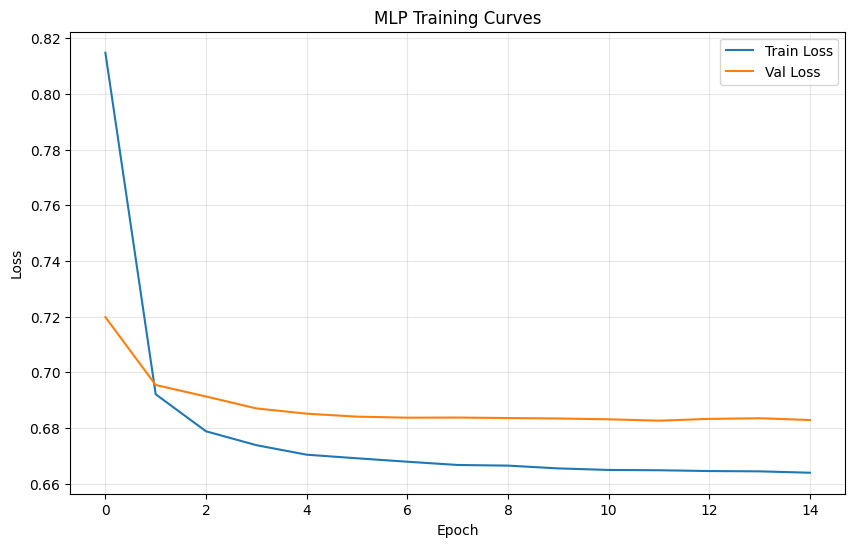

In [28]:
# Plot training curves for MLP
plot_train_val_curves(mlp_train_losses, mlp_val_losses, title="MLP Training Curves")

In [29]:
# optimize thresholds on val set first, then evaluate on test
mlp_val_results = model_evaluation(mlp_model, mlp_val_loader, labels, device)
mlp_thresholds = optimize_thresholds(mlp_val_results['targets'], mlp_val_results['probs'])

print("Optimal thresholds:")
for label, threshold in zip(labels, mlp_thresholds.round(2)):
    print(f"  {label:20s}: {threshold:.2f}")

mlp_results = model_evaluation(mlp_model, mlp_test_loader, labels, device, thresholds=mlp_thresholds)

print("\nAUC-ROC:")
for label, auc in mlp_results['per_class_auc'].items():
    print(f"  {label:20s}: {auc:.4f}")



Optimal thresholds:
  Atelectasis         : 0.50
  Cardiomegaly        : 0.20
  Consolidation       : 0.25
  Edema               : 0.40
  Effusion            : 0.50
  Emphysema           : 0.30
  Fibrosis            : 0.20
  Hernia              : 0.50
  Infiltration        : 0.50
  Mass                : 0.30
  No Finding          : 0.40
  Nodule              : 0.35
  Pleural_Thickening  : 0.25
  Pneumonia           : 0.10
  Pneumothorax        : 0.40

AUC-ROC:
  Atelectasis         : 0.5406
  Cardiomegaly        : 0.5195
  Consolidation       : 0.5815
  Edema               : 0.6920
  Effusion            : 0.5793
  Emphysema           : 0.5272
  Fibrosis            : 0.6372
  Hernia              : 0.8452
  Infiltration        : 0.6296
  Mass                : 0.5376
  No Finding          : 0.6167
  Nodule              : 0.5581
  Pleural_Thickening  : 0.5678
  Pneumonia           : 0.5043
  Pneumothorax        : 0.6418


In [30]:
# Print mean AUC-ROC, Mirco and Macro F1, mAP, and Classification Report

print(f"Mean AUC-ROC: {mlp_results['mean_auc']:.4f}")
print(f"Macro F1: {mlp_results['macro_f1']:.4f}")
print(f"Micro F1: {mlp_results['micro_f1']:.4f}")
print(f"mAP: {mlp_results['mAP']:.4f}")

print("\nClassification Report:")
print(mlp_results['report'])

torch.save(mlp_model.state_dict(), '../data/models/mlp_best.pt')
print("saved to ../data/models/mlp_best.pt")

Mean AUC-ROC: 0.5986
Macro F1: 0.1688
Micro F1: 0.2861
mAP: 0.1311

Classification Report:
                    precision    recall  f1-score   support

       Atelectasis       0.14      0.81      0.23      3279
      Cardiomegaly       0.05      0.12      0.07      1069
     Consolidation       0.09      0.56      0.16      1815
             Edema       0.07      0.33      0.11       925
          Effusion       0.21      0.91      0.34      4658
         Emphysema       0.14      0.00      0.01      1093
          Fibrosis       0.04      0.21      0.07       435
            Hernia       0.00      0.00      0.00        86
      Infiltration       0.27      0.89      0.42      6112
              Mass       0.08      0.57      0.13      1748
        No Finding       0.41      0.82      0.54      9860
            Nodule       0.08      0.36      0.14      1623
Pleural_Thickening       0.07      0.27      0.11      1143
         Pneumonia       0.02      0.28      0.04       555
      Pn

# Custom CNN Model

In [31]:
# Define Custom CNN Model

class CNN(nn.Module):

    def __init__(self):
        super().__init__()

         # Conv2d -> Batch Normalization -> Relu -> Maxpool
         # Normalizes activations before RelU to stabalize training using batchnorm

        # Layer 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3) 
        self.bn1 = nn.BatchNorm2d(64) # normalizes all 64 channels 
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) 

        # Layer 2
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3) 
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) 

        # Layer 3
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3) 
        self.bn3 = nn.BatchNorm2d(16)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # fully connected
        self.fc1 = nn.Linear(16 * 14 * 14, 32)
        self.dropout = nn.Dropout(0.5) # Drop out to randomly zero 50% of all neurons during training
        self.fc2 = nn.Linear(32, 15) # outputs 15 logits, one per label class

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

print(CNN())

CNN(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=32, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=32, out_features=15, bias=True)
)


In [32]:
# Create grayscale dataloaders for custom CNN (1-channel, 128x128)
def create_cnn_dataloaders(batch_size=128):

    # Create grayscale, resizing image, and convert to tensor
    gray_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1), # grayscale conversion
        transforms.Resize((128, 128)), # reshape to 128 x 128
        transforms.ToTensor(), # convert to PyTorch Tensor
    ])

    # Wrap raw data in PyTorch Dataset objects and apply transformations
    train_ds = ChestXrayDataset(train_cnn_X, train_cnn_y, transform = gray_transform)
    val_ds   = ChestXrayDataset(val_cnn_X,   val_cnn_y,   transform = gray_transform)
    test_ds  = ChestXrayDataset(test_cnn_X,  test_cnn_y,  transform = gray_transform)

    # Wrap datasets in dataloader for batched iteration
    train_loader = DataLoader(train_ds, batch_size = batch_size, shuffle = True,  num_workers = 0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size = batch_size, shuffle = False, num_workers = 0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size = batch_size, shuffle = False, num_workers = 0, pin_memory=True)

    return train_loader, val_loader, test_loader

# Initialize train, val, and test loaders
cnn_train_loader, cnn_val_loader, cnn_test_loader = create_cnn_dataloaders()

# Print dataset sizes
print(f"Train: {len(cnn_train_loader.dataset)}")
print(f"Val: {len(cnn_val_loader.dataset)}")
print(f"Test: {len(cnn_test_loader.dataset)}")


Train: 14863
Val: 3702
Test: 25595


In [33]:
cnn_model = CNN().to(device)

cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=1e-4)
cnn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(cnn_optimizer, mode='min', factor=0.5, patience=3)
cnn_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"Total parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")

Total parameters: 124,831


In [34]:
num_epochs = 15
patience = 5
best_val_loss = float('inf')
patience_counter = 0

cnn_train_losses = []
cnn_val_losses = []

for epoch in range(num_epochs):

    # train
    cnn_model.train()
    running_loss = 0.0
    total_samples = 0

    for i, (imgs, batch_labels) in enumerate(cnn_train_loader):
        imgs = imgs.to(device)
        batch_labels = batch_labels.to(device).float()

        cnn_optimizer.zero_grad()
        outputs = cnn_model(imgs)
        loss = cnn_criterion(outputs, batch_labels)
        loss.backward()
        cnn_optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        total_samples += imgs.size(0)

        if i % 10 == 0:
            print(f'  Epoch [{epoch+1}/{num_epochs}], Batch {i+1}, Loss: {loss.item():.4f}')

    avg_train_loss = running_loss / total_samples
    cnn_train_losses.append(avg_train_loss)

    # validation
    cnn_model.eval()
    val_running_loss = 0.0
    val_total_samples = 0

    with torch.no_grad():
        for imgs, batch_labels in cnn_val_loader:
            imgs = imgs.to(device)
            batch_labels = batch_labels.to(device).float()

            outputs = cnn_model(imgs)
            loss = cnn_criterion(outputs, batch_labels)

            val_running_loss += loss.item() * imgs.size(0)
            val_total_samples += imgs.size(0)

    avg_val_loss = val_running_loss / val_total_samples
    cnn_val_losses.append(avg_val_loss)

    cnn_scheduler.step(avg_val_loss)
    current_lr = cnn_optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - LR: {current_lr:.6f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_cnn_state = cnn_model.state_dict().copy()
        print(f"  new best: {avg_val_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"early stopping at epoch {epoch+1}")
            break

cnn_model.load_state_dict(best_cnn_state)
print(f"\nCNN training done. Best val loss: {best_val_loss:.4f}")
plot_train_val_curves(cnn_train_losses, cnn_val_losses, title="Custom CNN Training Curves")

  Epoch [1/15], Batch 1, Loss: 0.9335
  Epoch [1/15], Batch 11, Loss: 0.8554
  Epoch [1/15], Batch 21, Loss: 0.9020
  Epoch [1/15], Batch 31, Loss: 0.8619
  Epoch [1/15], Batch 41, Loss: 0.8630
  Epoch [1/15], Batch 51, Loss: 0.8615
  Epoch [1/15], Batch 61, Loss: 0.8789
  Epoch [1/15], Batch 71, Loss: 0.7913
  Epoch [1/15], Batch 81, Loss: 0.8213
  Epoch [1/15], Batch 91, Loss: 0.8469
  Epoch [1/15], Batch 101, Loss: 0.8675
  Epoch [1/15], Batch 111, Loss: 0.8159
Epoch [1/15] - Train Loss: 0.8555 - Val Loss: 0.7921 - LR: 0.000100
  new best: 0.7921
  Epoch [2/15], Batch 1, Loss: 0.8509
  Epoch [2/15], Batch 11, Loss: 0.8233
  Epoch [2/15], Batch 21, Loss: 0.7887
  Epoch [2/15], Batch 31, Loss: 0.8475
  Epoch [2/15], Batch 41, Loss: 0.7626
  Epoch [2/15], Batch 51, Loss: 0.8923


KeyboardInterrupt: 

In [ ]:
# evaluate CNN on test set
cnn_val_results = model_evaluation(cnn_model, cnn_val_loader, labels, device)
cnn_thresholds = optimize_thresholds(cnn_val_results['targets'], cnn_val_results['probs'])
print(f"Optimal thresholds: {dict(zip(labels, cnn_thresholds.round(2)))}\n")

cnn_results = model_evaluation(cnn_model, cnn_test_loader, labels, device, thresholds=cnn_thresholds)

print("Per-Class AUC-ROC:")
for name, auc in cnn_results['per_class_auc'].items():
    print(f"  {name:20s}: {auc:.4f}")

print(f"\nMean AUC-ROC: {cnn_results['mean_auc']:.4f}")
print(f"Macro F1: {cnn_results['macro_f1']:.4f}")
print(f"Micro F1: {cnn_results['micro_f1']:.4f}")
print(f"mAP: {cnn_results['mAP']:.4f}")
print("\nClassification Report:")
print(cnn_results['report'])

torch.save(cnn_model.state_dict(), '../data/models/cnn_best.pt')
print("saved to ../data/models/cnn_best.pt")

Optimal thresholds: {'Atelectasis': 0.55, 'Cardiomegaly': 0.35, 'Consolidation': 0.35, 'Edema': 0.35, 'Effusion': 0.6, 'Emphysema': 0.2, 'Fibrosis': 0.25, 'Hernia': 0.2, 'Infiltration': 0.55, 'Mass': 0.45, 'No Finding': 0.45, 'Nodule': 0.2, 'Pleural_Thickening': 0.15, 'Pneumonia': 0.25, 'Pneumothorax': 0.35}

Per-Class AUC-ROC:
  Atelectasis         : 0.6443
  Cardiomegaly        : 0.7331
  Consolidation       : 0.6807
  Edema               : 0.7425
  Effusion            : 0.7410
  Emphysema           : 0.5735
  Fibrosis            : 0.5398
  Hernia              : 0.4764
  Infiltration        : 0.6312
  Mass                : 0.5339
  No Finding          : 0.6665
  Nodule              : 0.5445
  Pleural_Thickening  : 0.5898
  Pneumonia           : 0.6010
  Pneumothorax        : 0.6080

Mean AUC-ROC: 0.6204
Macro F1: 0.1882
Micro F1: 0.2722
mAP: 0.1433

Classification Report:
                    precision    recall  f1-score   support

       Atelectasis       0.19      0.61      0.29   

# ResNet18 Model

In [ ]:
# Create 3-channel dataloaders for pretrained ResNet18
train_loader, val_loader, test_loader = create_dataloaders(channels=3, batch_size=128)
print(f"Train: {len(train_loader.dataset)}\nVal: {len(val_loader.dataset)}\nTest: {len(test_loader.dataset)}")

Train: 14858
Val: 3734
Test: 14777


In [ ]:
# load pretrained ResNet18 and swap out the final FC layer
resnet_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(resnet_model.fc.in_features, 15)
)
resnet_model = resnet_model.to(device)

print(resnet_model)
print(f"\nTotal parameters: {sum(p.numel() for p in resnet_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in resnet_model.parameters() if p.requires_grad):,}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# use different learning rates for the head vs. the backbone
resnet_optimizer = optim.Adam([
    {'params': resnet_model.fc.parameters(), 'lr': 1e-3},
    {'params': [p for n, p in resnet_model.named_parameters() if 'fc' not in n], 'lr': 1e-4}
], weight_decay=1e-4)

resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(resnet_optimizer, mode='min', factor=0.5, patience=3)
resnet_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

backbone frozen, training head only for 3 epochs
Epoch [1/15] | Train Loss: 0.7478 | Val Loss: 0.6612 | LR: 0.001000
  new best: 0.6612
Epoch [2/15] | Train Loss: 0.6845 | Val Loss: 0.6506 | LR: 0.001000
  new best: 0.6506
Epoch [3/15] | Train Loss: 0.6667 | Val Loss: 0.6524 | LR: 0.001000
backbone unfrozen, full fine-tuning now
Epoch [4/15] | Train Loss: 0.6333 | Val Loss: 0.6074 | LR: 0.001000
  new best: 0.6074
Epoch [5/15] | Train Loss: 0.5663 | Val Loss: 0.6164 | LR: 0.001000
Epoch [6/15] | Train Loss: 0.5206 | Val Loss: 0.6178 | LR: 0.001000
Epoch [7/15] | Train Loss: 0.4699 | Val Loss: 0.6731 | LR: 0.001000
Epoch [8/15] | Train Loss: 0.4236 | Val Loss: 0.6769 | LR: 0.000500
Epoch [9/15] | Train Loss: 0.3521 | Val Loss: 0.6983 | LR: 0.000500
early stopping at epoch 9

ResNet18 done. Best val loss: 0.6074


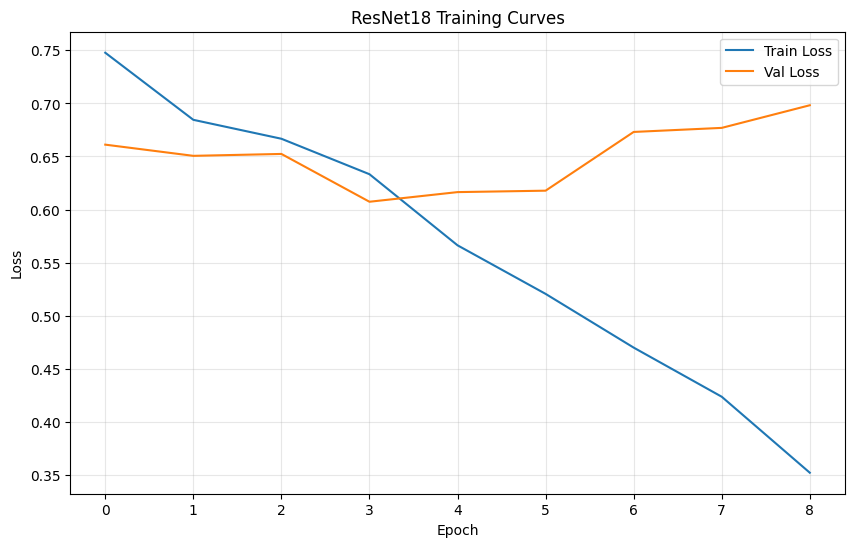

In [ ]:
num_epochs = 15
patience = 5
warmup_epochs = 3
best_val_loss = float('inf')
patience_counter = 0

# freeze backbone for first few epochs, only train the new head
for name, param in resnet_model.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False
print(f"backbone frozen, training head only for {warmup_epochs} epochs")

resnet_train_losses = []
resnet_val_losses = []

for epoch in range(num_epochs):

    if epoch == warmup_epochs:
        for param in resnet_model.parameters():
            param.requires_grad = True
        print("backbone unfrozen, full fine-tuning now")

    # train
    resnet_model.train()
    running_loss = 0.0
    total_samples = 0

    for imgs, batch_labels in train_loader:
        imgs = imgs.to(device)
        batch_labels = batch_labels.to(device).float()

        resnet_optimizer.zero_grad()
        outputs = resnet_model(imgs)
        loss = resnet_criterion(outputs, batch_labels)
        loss.backward()
        resnet_optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        total_samples += imgs.size(0)

    avg_train_loss = running_loss / total_samples
    resnet_train_losses.append(avg_train_loss)

    # validation
    resnet_model.eval()
    val_running_loss = 0.0
    val_total_samples = 0

    with torch.no_grad():
        for imgs, batch_labels in val_loader:
            imgs = imgs.to(device)
            batch_labels = batch_labels.to(device).float()

            outputs = resnet_model(imgs)
            loss = resnet_criterion(outputs, batch_labels)

            val_running_loss += loss.item() * imgs.size(0)
            val_total_samples += imgs.size(0)

    avg_val_loss = val_running_loss / val_total_samples
    resnet_val_losses.append(avg_val_loss)

    resnet_scheduler.step(avg_val_loss)
    current_lr = resnet_optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_resnet_state = resnet_model.state_dict().copy()
        print(f"  new best: {avg_val_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"early stopping at epoch {epoch+1}")
            break

resnet_model.load_state_dict(best_resnet_state)
print(f"\nResNet18 done. Best val loss: {best_val_loss:.4f}")
plot_train_val_curves(resnet_train_losses, resnet_val_losses, title="ResNet18 Training Curves")

In [ ]:
# optimize thresholds on val, then evaluate on test
resnet_val_results = model_evaluation(resnet_model, val_loader, labels, device)
resnet_thresholds = optimize_thresholds(resnet_val_results['targets'], resnet_val_results['probs'])
print(f"Optimal thresholds: {dict(zip(labels, resnet_thresholds.round(2)))}\n")

resnet_results = model_evaluation(resnet_model, test_loader, labels, device, thresholds=resnet_thresholds)

print("Per-Class AUC-ROC:")
for name, auc in resnet_results['per_class_auc'].items():
    print(f"  {name:20s}: {auc:.4f}")

print(f"\nMean AUC-ROC: {resnet_results['mean_auc']:.4f}")
print(f"Macro F1:     {resnet_results['macro_f1']:.4f}")
print(f"Micro F1:     {resnet_results['micro_f1']:.4f}")
print(f"mAP:          {resnet_results['mAP']:.4f}")
print("\nClassification Report:")
print(resnet_results['report'])

torch.save(resnet_model.state_dict(), '../data/models/resnet18_best.pt')
print("saved to ../data/models/resnet18_best.pt")

Optimal thresholds: {'Atelectasis': 0.5, 'Cardiomegaly': 0.4, 'Consolidation': 0.45, 'Edema': 0.65, 'Effusion': 0.85, 'Emphysema': 0.35, 'Fibrosis': 0.45, 'Hernia': 0.5, 'Infiltration': 0.6, 'Mass': 0.3, 'No Finding': 0.2, 'Nodule': 0.6, 'Pleural_Thickening': 0.35, 'Pneumonia': 0.2, 'Pneumothorax': 0.25}

Per-Class AUC-ROC:
  Atelectasis         : 0.7040
  Cardiomegaly        : 0.8055
  Consolidation       : 0.6818
  Edema               : 0.7961
  Effusion            : 0.7948
  Emphysema           : 0.7331
  Fibrosis            : 0.6776
  Hernia              : 0.7649
  Infiltration        : 0.6431
  Mass                : 0.6793
  No Finding          : 0.7201
  Nodule              : 0.6388
  Pleural_Thickening  : 0.6532
  Pneumonia           : 0.6125
  Pneumothorax        : 0.7471

Mean AUC-ROC: 0.7101
Macro F1:     0.2348
Micro F1:     0.3766
mAP:          0.1862

Classification Report:
                    precision    recall  f1-score   support

       Atelectasis       0.22      0.66

# DenseNet121 Model

In [ ]:
# Create 3-channel dataloaders for DenseNet121
train_loader, val_loader, test_loader = create_dataloaders(channels=3, batch_size=128)
print(f"Train: {len(train_loader.dataset)}\nVal: {len(val_loader.dataset)}\nTest: {len(test_loader.dataset)}")

Train: 14858
Val: 3734
Test: 14777


In [ ]:
# load pretrained DenseNet121 and replace the classifier head
densenet_model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
densenet_model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(densenet_model.classifier.in_features, 15)
)
densenet_model = densenet_model.to(device)

print(f"Total parameters: {sum(p.numel() for p in densenet_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in densenet_model.parameters() if p.requires_grad):,}")

Total parameters: 6,969,231
Trainable parameters: 6,969,231


In [ ]:
# use different learning rates for the head vs. the backbone
densenet_optimizer = optim.Adam([
    {'params': densenet_model.classifier.parameters(), 'lr': 1e-3},
    {'params': [p for n, p in densenet_model.named_parameters() if 'classifier' not in n], 'lr': 1e-4}
], weight_decay=1e-4)

densenet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(densenet_optimizer, mode='min', factor=0.5, patience=3)
densenet_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

backbone frozen, training head only for 3 epochs
Epoch [1/15] | Train Loss: 0.7089 | Val Loss: 0.6496 | LR: 0.001000
  new best: 0.6496
Epoch [2/15] | Train Loss: 0.6599 | Val Loss: 0.6360 | LR: 0.001000
  new best: 0.6360
Epoch [3/15] | Train Loss: 0.6479 | Val Loss: 0.6296 | LR: 0.001000
  new best: 0.6296
backbone unfrozen, full fine-tuning now
Epoch [4/15] | Train Loss: 0.6258 | Val Loss: 0.5969 | LR: 0.001000
  new best: 0.5969
Epoch [5/15] | Train Loss: 0.5716 | Val Loss: 0.5931 | LR: 0.001000
  new best: 0.5931
Epoch [6/15] | Train Loss: 0.5306 | Val Loss: 0.5912 | LR: 0.001000
  new best: 0.5912
Epoch [7/15] | Train Loss: 0.5034 | Val Loss: 0.6123 | LR: 0.001000
Epoch [8/15] | Train Loss: 0.4727 | Val Loss: 0.6253 | LR: 0.001000
Epoch [9/15] | Train Loss: 0.4216 | Val Loss: 0.6546 | LR: 0.001000
Epoch [10/15] | Train Loss: 0.3930 | Val Loss: 0.7725 | LR: 0.000500
Epoch [11/15] | Train Loss: 0.3201 | Val Loss: 0.7872 | LR: 0.000500
early stopping at epoch 11

DenseNet121 done. B

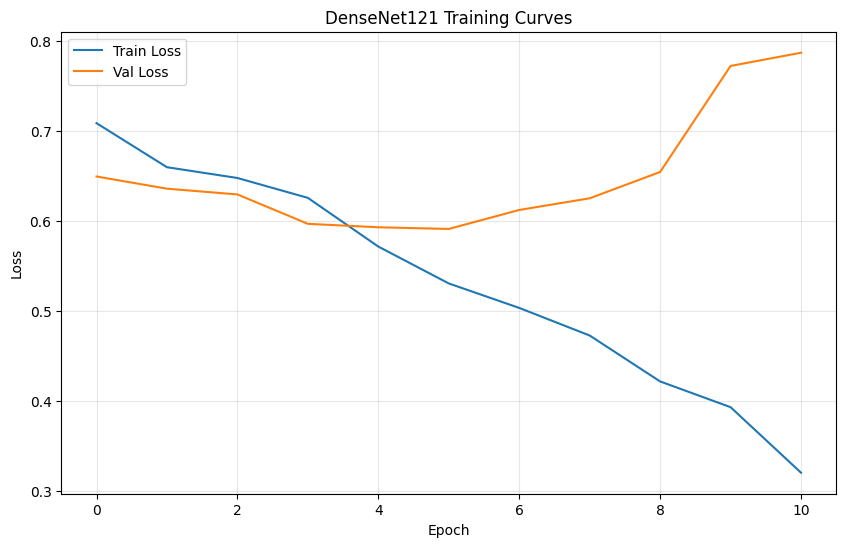

In [ ]:
num_epochs = 15
patience = 5
warmup_epochs = 3
best_val_loss = float('inf')
patience_counter = 0

# freeze backbone, only train classifier head first
for name, param in densenet_model.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False
print(f"backbone frozen, training head only for {warmup_epochs} epochs")

densenet_train_losses = []
densenet_val_losses = []

for epoch in range(num_epochs):

    if epoch == warmup_epochs:
        for param in densenet_model.parameters():
            param.requires_grad = True
        print("backbone unfrozen, full fine-tuning now")

    # train
    densenet_model.train()
    running_loss = 0.0
    total_samples = 0

    for imgs, batch_labels in train_loader:
        imgs = imgs.to(device)
        batch_labels = batch_labels.to(device).float()

        densenet_optimizer.zero_grad()
        outputs = densenet_model(imgs)
        loss = densenet_criterion(outputs, batch_labels)
        loss.backward()
        densenet_optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        total_samples += imgs.size(0)

    avg_train_loss = running_loss / total_samples
    densenet_train_losses.append(avg_train_loss)

    # validation
    densenet_model.eval()
    val_running_loss = 0.0
    val_total_samples = 0

    with torch.no_grad():
        for imgs, batch_labels in val_loader:
            imgs = imgs.to(device)
            batch_labels = batch_labels.to(device).float()

            outputs = densenet_model(imgs)
            loss = densenet_criterion(outputs, batch_labels)

            val_running_loss += loss.item() * imgs.size(0)
            val_total_samples += imgs.size(0)

    avg_val_loss = val_running_loss / val_total_samples
    densenet_val_losses.append(avg_val_loss)

    densenet_scheduler.step(avg_val_loss)
    current_lr = densenet_optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_densenet_state = densenet_model.state_dict().copy()
        print(f"  new best: {avg_val_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"early stopping at epoch {epoch+1}")
            break

densenet_model.load_state_dict(best_densenet_state)
print(f"\nDenseNet121 done. Best val loss: {best_val_loss:.4f}")
plot_train_val_curves(densenet_train_losses, densenet_val_losses, title="DenseNet121 Training Curves")

In [ ]:
# optimize thresholds on val, then evaluate on test
densenet_val_results = model_evaluation(densenet_model, val_loader, labels, device)
densenet_thresholds = optimize_thresholds(densenet_val_results['targets'], densenet_val_results['probs'])
print(f"Optimal thresholds: {dict(zip(labels, densenet_thresholds.round(2)))}\n")

densenet_results = model_evaluation(densenet_model, test_loader, labels, device, thresholds=densenet_thresholds)

print("Per-Class AUC-ROC:")
for name, auc in densenet_results['per_class_auc'].items():
    print(f"  {name:20s}: {auc:.4f}")

print(f"\nMean AUC-ROC: {densenet_results['mean_auc']:.4f}")
print(f"Macro F1:     {densenet_results['macro_f1']:.4f}")
print(f"Micro F1:     {densenet_results['micro_f1']:.4f}")
print(f"mAP:          {densenet_results['mAP']:.4f}")
print("\nClassification Report:")
print(densenet_results['report'])

torch.save(densenet_model.state_dict(), '../data/models/densenet121_best.pt')
print("saved to ../data/models/densenet121_best.pt")

Optimal thresholds: {'Atelectasis': 0.65, 'Cardiomegaly': 0.3, 'Consolidation': 0.2, 'Edema': 0.1, 'Effusion': 0.6, 'Emphysema': 0.4, 'Fibrosis': 0.5, 'Hernia': 0.5, 'Infiltration': 0.55, 'Mass': 0.35, 'No Finding': 0.3, 'Nodule': 0.55, 'Pleural_Thickening': 0.25, 'Pneumonia': 0.2, 'Pneumothorax': 0.2}

Per-Class AUC-ROC:
  Atelectasis         : 0.7202
  Cardiomegaly        : 0.8162
  Consolidation       : 0.6723
  Edema               : 0.8050
  Effusion            : 0.8049
  Emphysema           : 0.7577
  Fibrosis            : 0.7017
  Hernia              : 0.7874
  Infiltration        : 0.6433
  Mass                : 0.6933
  No Finding          : 0.7020
  Nodule              : 0.6387
  Pleural_Thickening  : 0.6920
  Pneumonia           : 0.6010
  Pneumothorax        : 0.7685

Mean AUC-ROC: 0.7203
Macro F1:     0.2448
Micro F1:     0.3725
mAP:          0.2024

Classification Report:
                    precision    recall  f1-score   support

       Atelectasis       0.28      0.41  

# Model Comparison and Analysis

In [ ]:
all_results = {
    'MLP': mlp_results,
    'CNN': cnn_results,
    'ResNet18': resnet_results,
    'DenseNet121': densenet_results,
}

print('=' * 70)
print(f"{'Metric':<20} {'MLP':>10} {'CNN':>10} {'ResNet18':>10} {'DenseNet121':>10}")
print('=' * 70)

mlp_auc   = mlp_results['mean_auc']
cnn_auc   = cnn_results['mean_auc']
rn_auc    = resnet_results['mean_auc']
dn_auc    = densenet_results['mean_auc']
print(f"{'Mean AUC-ROC':<20} {mlp_auc:>10.4f} {cnn_auc:>10.4f} {rn_auc:>10.4f} {dn_auc:>10.4f}")

mlp_f1  = mlp_results['macro_f1']
cnn_f1  = cnn_results['macro_f1']
rn_f1   = resnet_results['macro_f1']
dn_f1   = densenet_results['macro_f1']
print(f"{'Macro F1':<20} {mlp_f1:>10.4f} {cnn_f1:>10.4f} {rn_f1:>10.4f} {dn_f1:>10.4f}")

mlp_map  = mlp_results['mAP']
cnn_map  = cnn_results['mAP']
rn_map   = resnet_results['mAP']
dn_map   = densenet_results['mAP']
print(f"{'mAP':<20} {mlp_map:>10.4f} {cnn_map:>10.4f} {rn_map:>10.4f} {dn_map:>10.4f}")

mlp_params = sum(p.numel() for p in mlp_model.parameters())
cnn_params = sum(p.numel() for p in cnn_model.parameters())
rn_params  = sum(p.numel() for p in resnet_model.parameters())
dn_params  = sum(p.numel() for p in densenet_model.parameters())
print(f"{'Parameters':<20} {mlp_params:>10,} {cnn_params:>10,} {rn_params:>10,} {dn_params:>10,}")
print('=' * 70)

print(f"\n{'Disease':<22} {'MLP':>8} {'CNN':>10} {'ResNet18':>12} {'DenseNet121':>12}")
print('-' * 64)
for name in labels:
    aucs = [all_results[m]['per_class_auc'].get(name, float('nan')) for m in all_results]
    print(f"{name:<22} {aucs[0]:>8.4f} {aucs[1]:>10.4f} {aucs[2]:>12.4f} {aucs[3]:>12.4f}")

Metric                      MLP        CNN   ResNet18 DenseNet121
Mean AUC-ROC             0.6332     0.6204     0.7101     0.7203
Macro F1                 0.1777     0.1882     0.2348     0.2448
mAP                      0.1349     0.1433     0.1862     0.2024
Parameters                2,895    124,831 11,184,207  6,969,231

Disease                     MLP        CNN     ResNet18  DenseNet121
----------------------------------------------------------------
Atelectasis              0.5824     0.6443       0.7040       0.7202
Cardiomegaly             0.5549     0.7331       0.8055       0.8162
Consolidation            0.6502     0.6807       0.6818       0.6723
Edema                    0.7440     0.7425       0.7961       0.8050
Effusion                 0.6350     0.7410       0.7948       0.8049
Emphysema                0.6044     0.5735       0.7331       0.7577
Fibrosis                 0.7094     0.5398       0.6776       0.7017
Hernia                   0.8231     0.4764       0.7649 

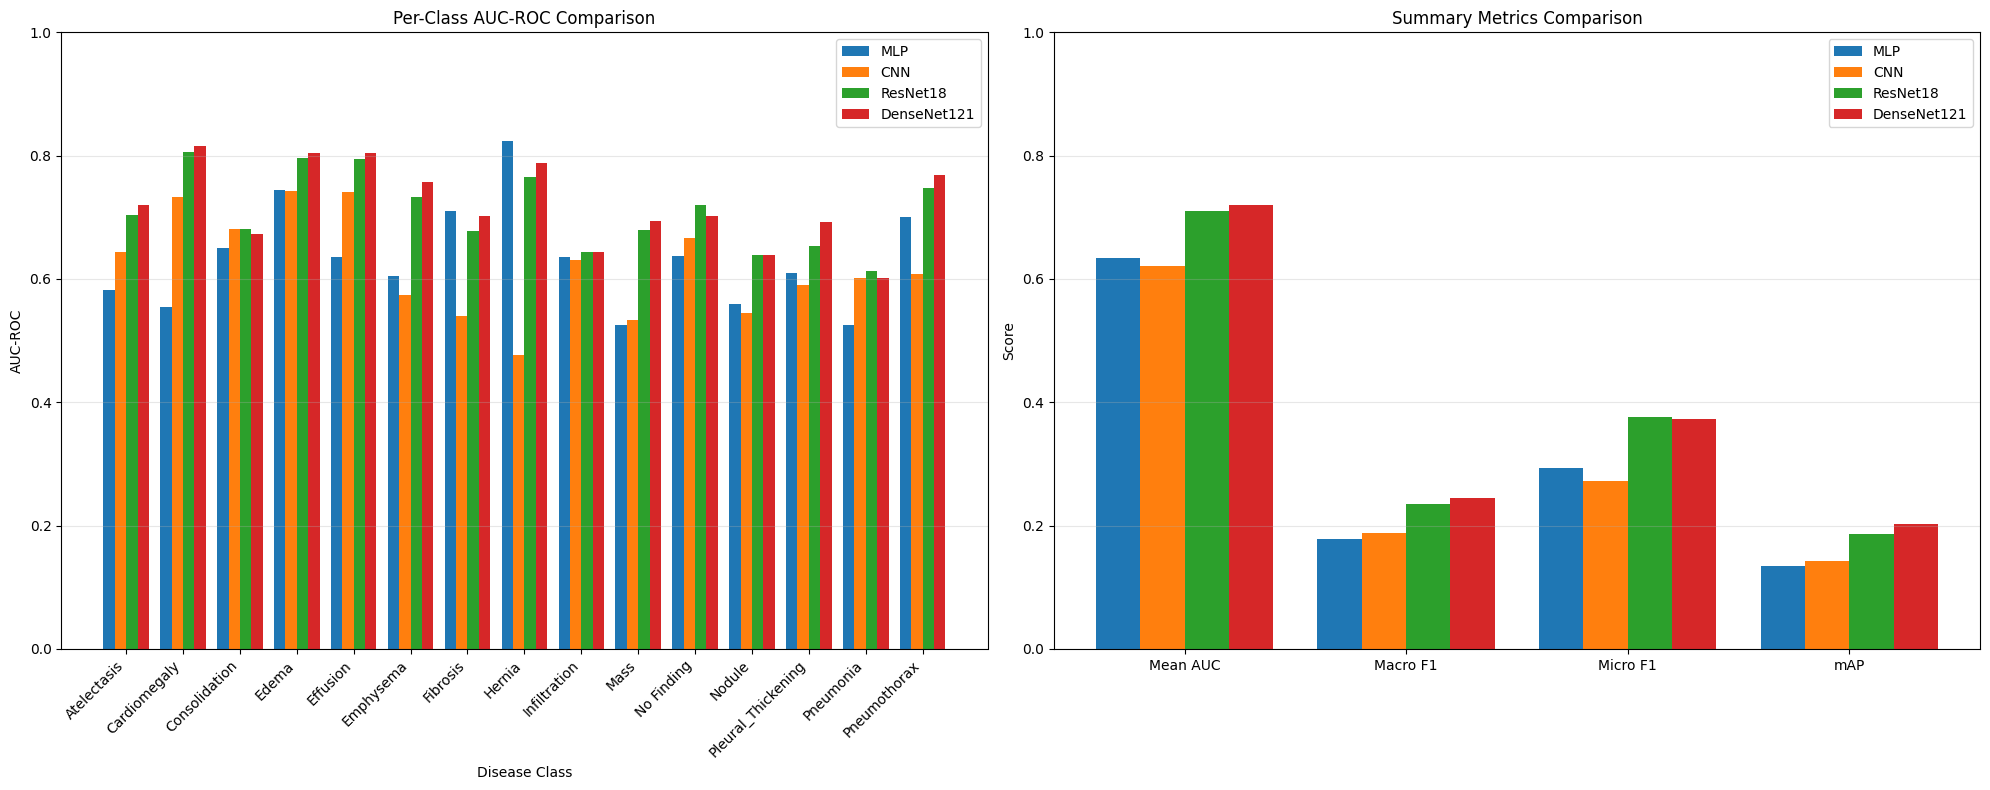

In [ ]:
# Visual comparison charts
comparison_plot(all_results, labels)

Showing PR curves for best model: DenseNet121 (Mean AUC: 0.7203)



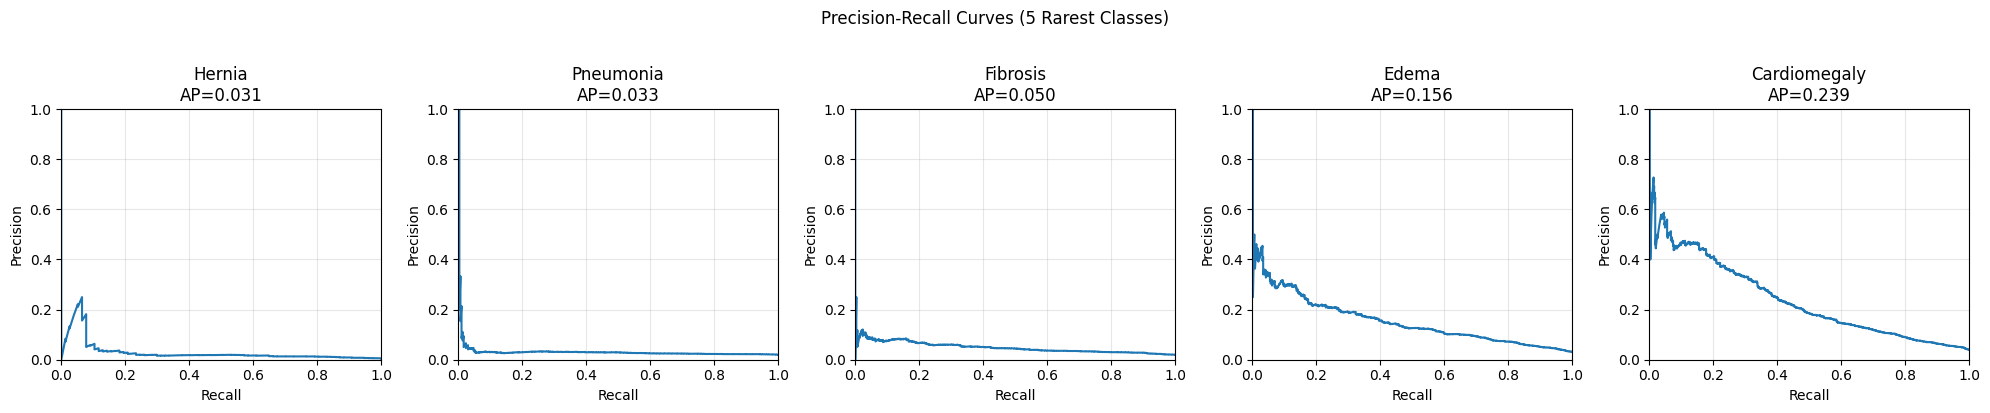

In [ ]:
# Precision-Recall curves for the 5 rarest classes (using best model's predictions)

# Find best model by mean AUC
best_model_name = max(all_results, key=lambda k: all_results[k]['mean_auc'])
best_results = all_results[best_model_name]
print(f"Showing PR curves for best model: {best_model_name} (Mean AUC: {best_results['mean_auc']:.4f})\n")

plot_precision_recall_curves(best_results['targets'], best_results['probs'], labels, top_n=5)

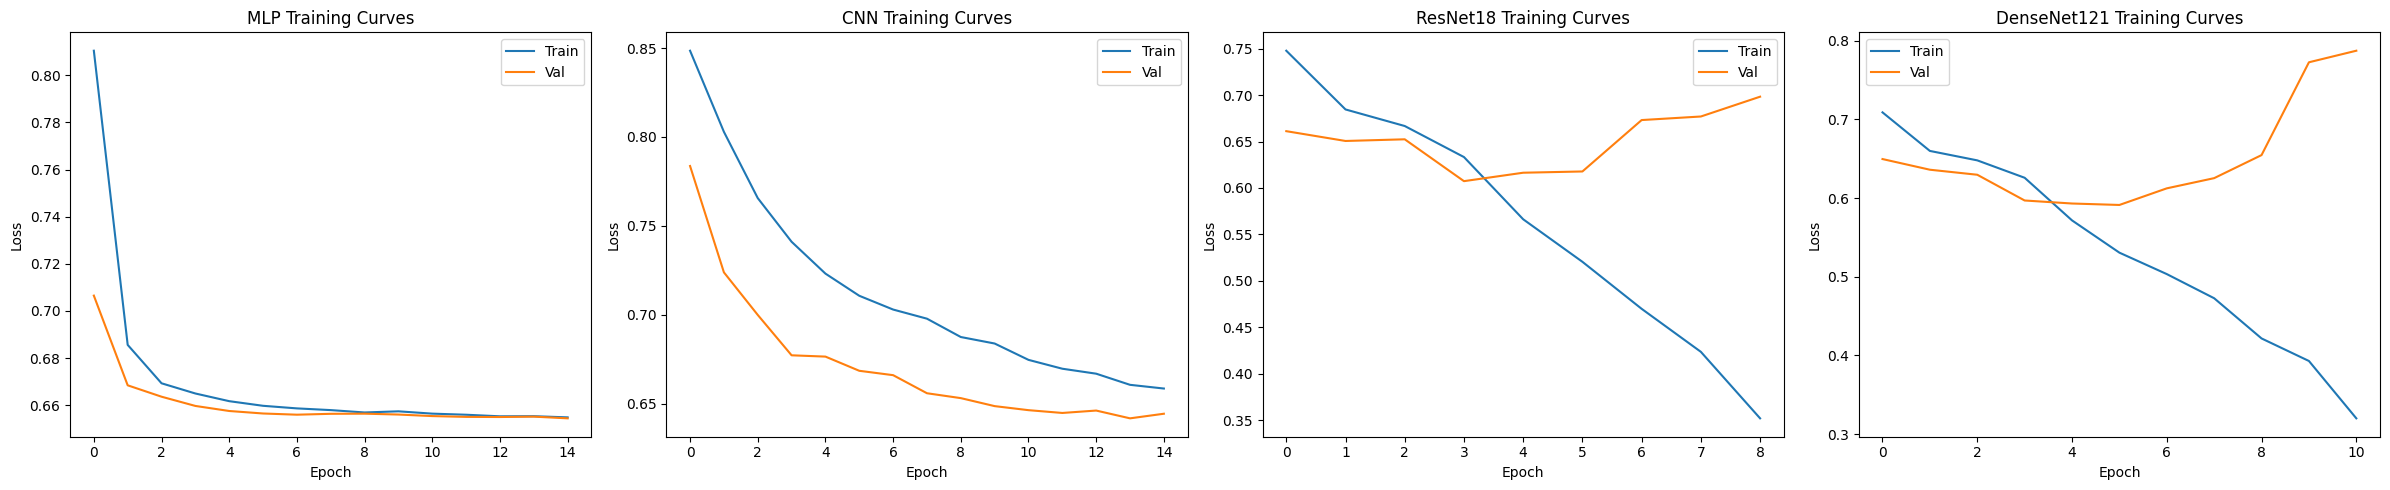

In [ ]:
plt.figure(figsize=(24, 5))

plt.subplot(1, 4, 1)
plt.plot(mlp_train_losses, label='Train')
plt.plot(mlp_val_losses, label='Val')
plt.title('MLP Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 4, 2)
plt.plot(cnn_train_losses, label='Train')
plt.plot(cnn_val_losses, label='Val')
plt.title('CNN Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 4, 3)
plt.plot(resnet_train_losses, label='Train')
plt.plot(resnet_val_losses, label='Val')
plt.title('ResNet18 Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 4, 4)
plt.plot(densenet_train_losses, label='Train')
plt.plot(densenet_val_losses, label='Val')
plt.title('DenseNet121 Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()